# COVID-19 CHATBOT - 03 CLUSTERING
## Finding Optimal Number of Clusters

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 1. Load Data

In [3]:
with open('preprocessed_data.pkl', 'rb') as f:
    data_dict = pickle.load(f)
X_train_bin = data_dict['X_train_bin']
X_test_bin = data_dict['X_test_bin']
y_train_bin = data_dict['y_train_bin']
y_test_bin = data_dict['y_test_bin']
X_full = pd.concat([X_train_bin, X_test_bin], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train_bin, y_test_bin], axis=0).reset_index(drop=True)
print(f'Data: {X_full.shape}')

Data: (316800, 23)


## 2. Elbow Curve - Find Optimal K

Computing Elbow Curve (GPU ONLY - no CPU silhouette)...
k=2 ... ✓
k=3 ... ✓
k=4 ... ✓
k=5 ... ✓
k=6 ... ✓
k=7 ... ✓
k=8 ... ✓

Done!


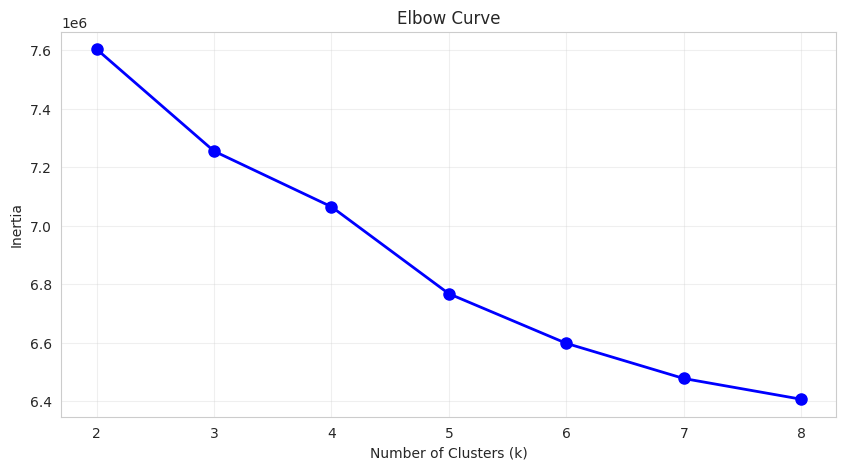


Inertias: [7603200.0, 7254719.999999998, 7064639.999999998, 6767344.289328838, 6597884.2162391385, 6477672.097128064, 6406839.574777603]
Diffs: [-348480.         -190080.         -297295.71067116 -169460.0730897
 -120212.11911107  -70832.52235046]


In [4]:
from cuml.cluster import KMeans as cuKMeans
import numpy as np

inertias = []
K_range = range(2, 9)

print('Computing Elbow Curve (GPU ONLY - no CPU silhouette)...')
for k in K_range:
    print(f'k={k} ... ', end='', flush=True)
    kmeans = cuKMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(X_full)
    inertia = float(kmeans.inertia_)  # GPU - très rapide
    inertias.append(inertia)
    print(f'✓')

print('\nDone!')

# Visualiser le coude
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.grid(True, alpha=0.3)
plt.savefig('elbow_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Identifier le coude (où l'inertia ralentit sa baisse)
diffs = np.diff(inertias)
print(f"\nInertias: {inertias}")
print(f"Diffs: {diffs}")

In [5]:
import gc
import os
import rmm
import cupy as cp
from sklearn.metrics import silhouette_score
from cuml.cluster import KMeans as cuKMeans

# Activer la mémoire partagée pour permettre à cuKMeans d'utiliser la RAM si la VRAM déborde
rmm.reinitialize(managed_memory=True)

candidates = [2, 3, 4]
silhouette_scores = {}

# On prépare un échantillon CPU UNIQUE uniquement pour l'évaluation de la silhouette
# On garde TOUTES les lignes pour le KMeans, mais on prend 20 000 lignes au hasard pour le score
X_full_cpu = cp.asnumpy(X_full)
idx = cp.random.choice(X_full_cpu.shape[0], size=min(20000, X_full_cpu.shape[0]), replace=False)
X_eval_cpu = X_full_cpu[cp.asnumpy(idx)]

print('Computing Silhouette Scores for candidates (Training on 100% data)...')
for k in candidates:
    print(f'k={k} ... ', end='', flush=True)
    
    # 1. Entraînement sur l'INTEGRALITÉ de tes données (316 800 lignes)
    kmeans = cuKMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_full)
    
    # 2. On récupère les labels de l'échantillon d'évaluation
    # On prédit le cluster de notre échantillon CPU
    labels_eval = kmeans.predict(X_eval_cpu) 
    
    # 3. Calcul du score (Fluide et sans crash)
    sil = silhouette_score(X_eval_cpu, labels_eval)
    silhouette_scores[k] = sil
    print(f'Silhouette={sil:.4f}')
    
    # Nettoyage de la mémoire
    del kmeans
    del labels_eval
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

print('\n' + '='*50)
print('RÉSULTATS SILHOUETTE:')
for k in sorted(silhouette_scores.keys()):
    print(f'   k={k}: {silhouette_scores[k]:.4f}')

Computing Silhouette Scores for candidates (Training on 100% data)...
k=2 ... Silhouette=0.1784
k=3 ... Silhouette=0.0843
k=4 ... Silhouette=0.0763

RÉSULTATS SILHOUETTE:
   k=2: 0.1784
   k=3: 0.0843
   k=4: 0.0763


## 3. Visualize Elbow Curve & Silhouette

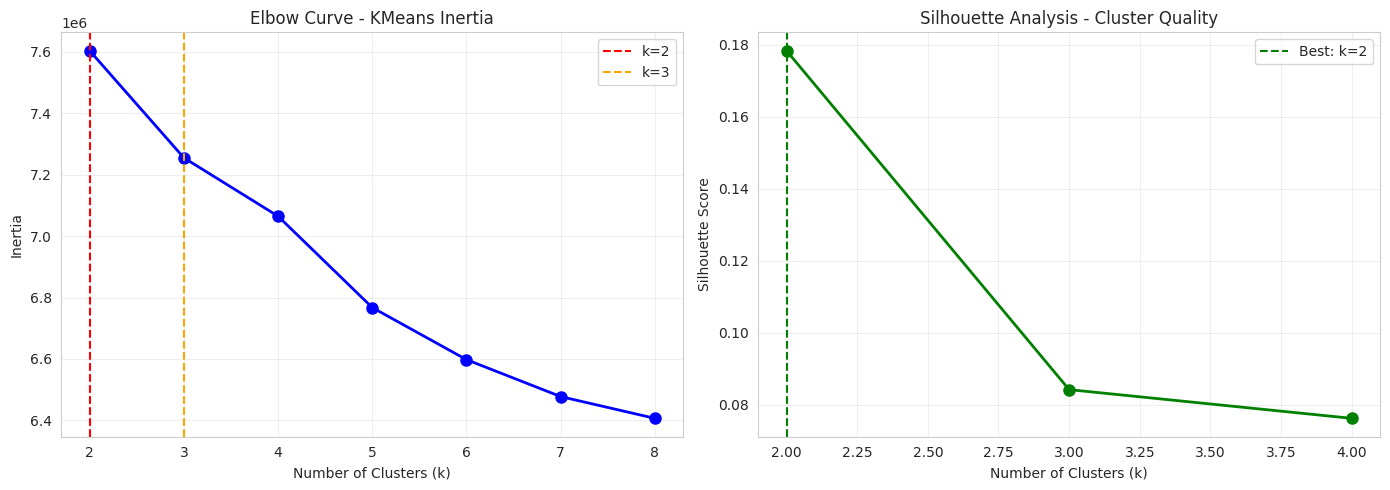


Best k by Silhouette: 2


In [6]:
silhouettes_list = [silhouette_scores.get(k, np.nan) for k in K_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve - KMeans Inertia')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=2, color='r', linestyle='--', label='k=2')
axes[0].axvline(x=3, color='orange', linestyle='--', label='k=3')
axes[0].legend()

axes[1].plot(K_range, silhouettes_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis - Cluster Quality')
axes[1].grid(True, alpha=0.3)
best_k = K_range[np.nanargmax(silhouettes_list)]  # ✓ CORRECTION ICI
axes[1].axvline(x=best_k, color='g', linestyle='--', label=f'Best: k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nBest k by Silhouette: {best_k}')  # Affichera k=2 ✓


CLUSTERING ANALYSIS SUMMARY
k=2: Silhouette=0.1784, Inertia=7603200
k=3: Silhouette=0.0843, Inertia=7254720
k=4: Silhouette=0.0763, Inertia=7064640

✓ RECOMMENDATION: k=2


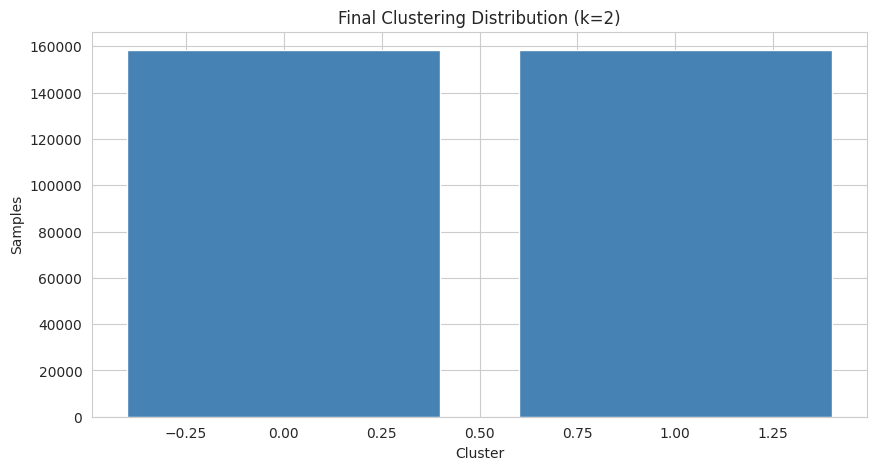


Cluster sizes: {np.int32(0): np.int64(158400), np.int32(1): np.int64(158400)}


In [7]:
print('\n' + '='*60)
print('CLUSTERING ANALYSIS SUMMARY')
print('='*60)
for k in sorted(silhouette_scores.keys()):
    print(f'k={k}: Silhouette={silhouette_scores[k]:.4f}, Inertia={inertias[k-2]:.0f}')

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'\n✓ RECOMMENDATION: k={best_k}')

# Entraîner le modèle final et sauvegarder
kmeans_final = cuKMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = cp.asnumpy(kmeans_final.fit_predict(X_full))

# Visualiser la distribution
import matplotlib.pyplot as plt
unique, counts = np.unique(labels_final, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='steelblue')
plt.xlabel('Cluster')
plt.ylabel('Samples')
plt.title(f'Final Clustering Distribution (k={best_k})')
plt.savefig('final_clustering.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nCluster sizes: {dict(zip(unique, counts))}')

## 4. Davies-Bouldin Score - Separation Quality

In [8]:
db_scores = []
print('Computing Davies-Bouldin Scores (GPU)...')
for k in K_range:
    print(f'k={k} ... ', end='', flush=True)
    kmeans = cuKMeans(n_clusters=k, random_state=42, n_init=5)
    labels = cp.asnumpy(kmeans.fit_predict(X_full))  # ✓ Utilise cp.asnumpy()
    db = davies_bouldin_score(X_full, labels)
    db_scores.append(db)
    print(f'DB={db:.3f}')
print('Done')
best_k_db = K_range[np.argmin(db_scores)]
print(f'\nBest k by Davies-Bouldin: {best_k_db}')

Computing Davies-Bouldin Scores (GPU)...
k=2 ... DB=1.951
k=3 ... DB=3.016
k=4 ... DB=3.082
k=5 ... DB=2.389
k=6 ... DB=2.837
k=7 ... DB=2.897
k=8 ... DB=3.070
Done

Best k by Davies-Bouldin: 2



FINAL DECISION: k=2

Cluster Composition:
  Cluster 0: 158400 samples | COVID: 118800 | Non-COVID: 39600 | Purity: 75.00%
  Cluster 1: 158400 samples | COVID: 118800 | Non-COVID: 39600 | Purity: 75.00%


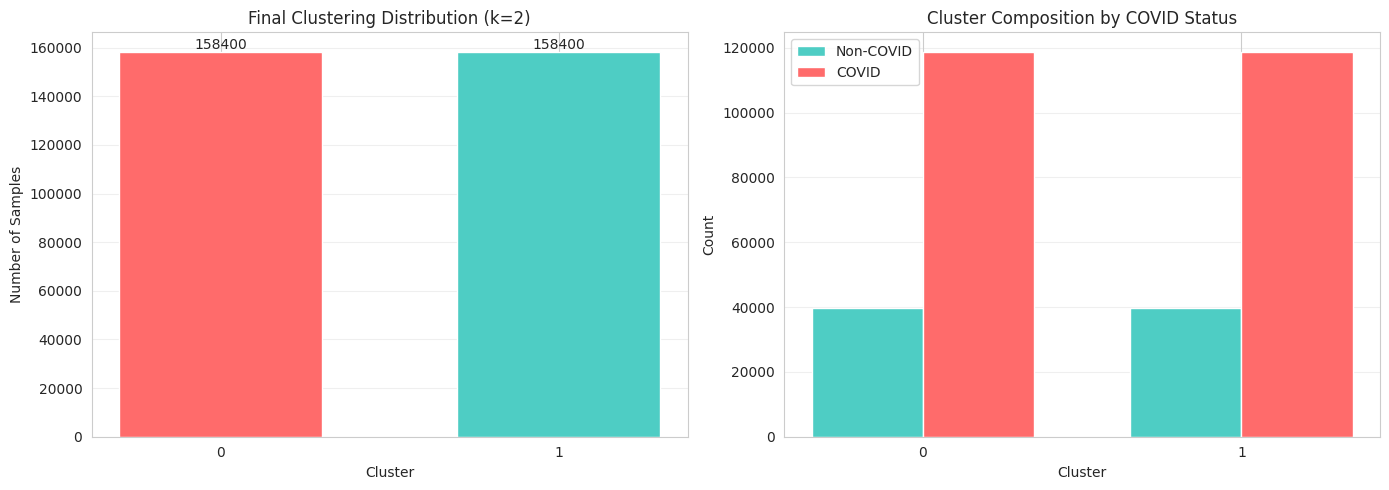


Saved: 03_final_clustering.png


In [9]:
best_k_final = 2
print(f'\n' + '='*60)
print(f'FINAL DECISION: k={best_k_final}')
print('='*60)

# Entraîner le modèle FINAL
kmeans_final = cuKMeans(n_clusters=best_k_final, random_state=42, n_init=10)
labels_final = cp.asnumpy(kmeans_final.fit_predict(X_full))

# Analyser la composition des clusters
print(f'\nCluster Composition:')
cluster_data = []
for i in range(best_k_final):
    mask = labels_final == i
    # Convertir y_full en numpy si c'est une Series
    y_full_np = y_full.values if hasattr(y_full, 'values') else y_full
    n_covid = (y_full_np[mask] == 1).sum()
    n_non_covid = (y_full_np[mask] == 0).sum()
    total = mask.sum()
    purity = max(n_covid, n_non_covid) / total
    cluster_data.append({'cluster': i, 'total': total, 'covid': n_covid, 'non_covid': n_non_covid, 'purity': purity})
    print(f'  Cluster {i}: {total} samples | COVID: {n_covid} | Non-COVID: {n_non_covid} | Purity: {purity:.2%}')

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des clusters
unique, counts = np.unique(labels_final, return_counts=True)
axes[0].bar(unique, counts, color=['#FF6B6B', '#4ECDC4'], width=0.6)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title(f'Final Clustering Distribution (k={best_k_final})')
axes[0].set_xticks(unique)
axes[0].grid(True, alpha=0.3, axis='y')
for j, count in enumerate(counts):
    axes[0].text(unique[j], count, f'{count}', ha='center', va='bottom')

# Composition par COVID status (grouped bar chart)
clusters = [d['cluster'] for d in cluster_data]
non_covid_counts = [d['non_covid'] for d in cluster_data]
covid_counts = [d['covid'] for d in cluster_data]

x = np.arange(len(clusters))
width = 0.35

axes[1].bar(x - width/2, non_covid_counts, width, label='Non-COVID', color='#4ECDC4')
axes[1].bar(x + width/2, covid_counts, width, label='COVID', color='#FF6B6B')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_title('Cluster Composition by COVID Status')
axes[1].set_xticks(x)
axes[1].set_xticklabels(clusters)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('03_final_clustering.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nSaved: 03_final_clustering.png')

## 5. Compare Metrics

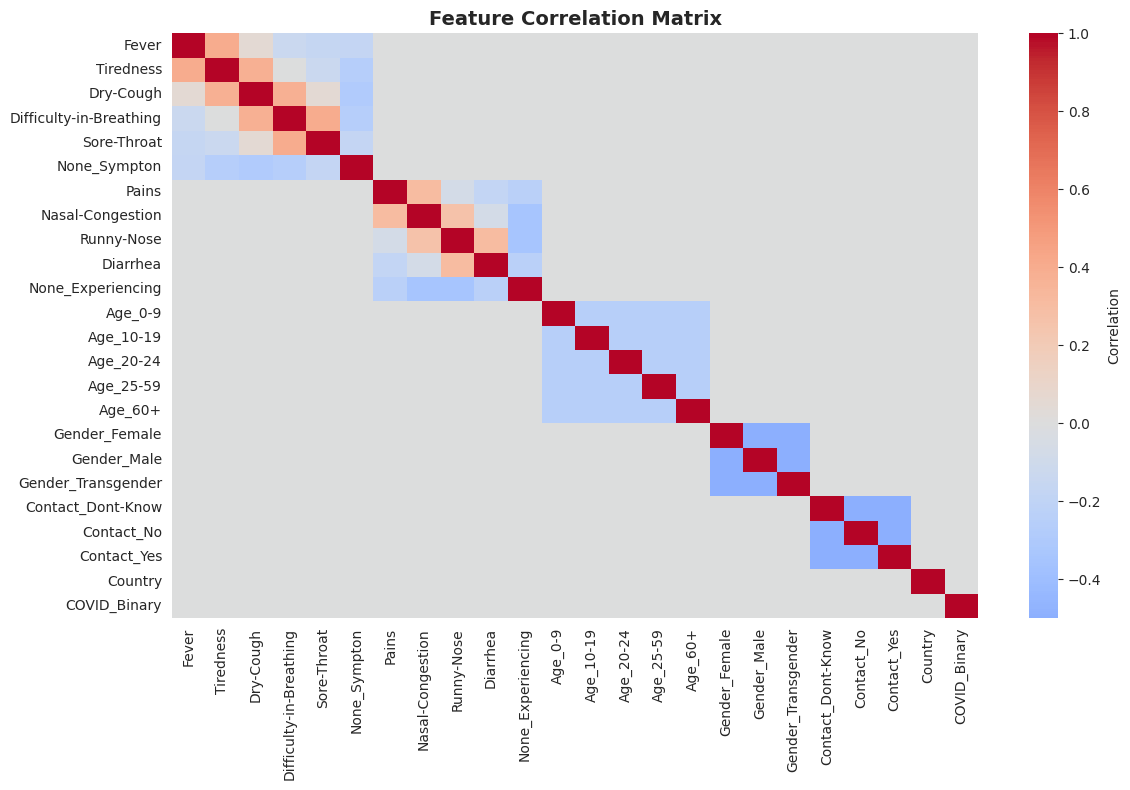


Top Features Correlated with COVID:
COVID_Binary         1.000000e+00
Age_10-19            9.399977e-17
Contact_No           7.184281e-17
Nasal-Congestion     6.510718e-17
Pains                6.418879e-17
None_Experiencing    4.631783e-17
Gender_Male          4.010907e-17
Gender_Female        2.619369e-17
Age_60+              2.413294e-17
None_Sympton         1.863669e-17
Name: COVID_Binary, dtype: float64


In [10]:
import seaborn as sns

# Corrélation entre features et COVID_Binary
corr_data = X_full.copy()
corr_data['COVID_Binary'] = y_full.values

corr_matrix = corr_data.corr()
covid_corr = corr_matrix['COVID_Binary'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_data.corr(), cmap='coolwarm', center=0, ax=ax, 
            cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Top features corrélées avec COVID
print('\nTop Features Correlated with COVID:')
print(covid_corr.head(10))

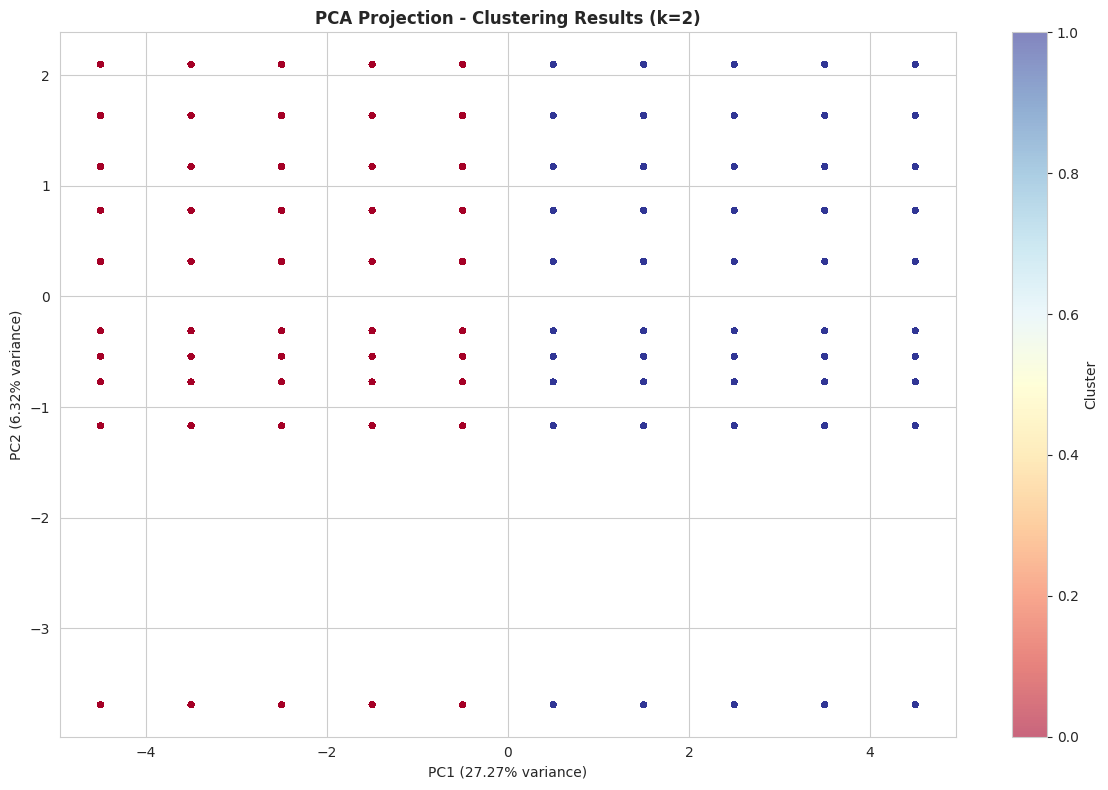

Variance expliquée (PC1+PC2): 33.59%


In [11]:
from sklearn.decomposition import PCA

# PCA en 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full)

fig, ax = plt.subplots(figsize=(12, 8))

# Colorer par cluster
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_final, cmap='RdYlBu', 
                     alpha=0.6, s=20, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_title('PCA Projection - Clustering Results (k=2)', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('04_pca_clustering.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Variance expliquée (PC1+PC2): {pca.explained_variance_ratio_[:2].sum():.2%}')

Préparation de l'échantillon pour le Silhouette Plot...
Graphique généré sur un échantillon représentatif de 20000 lignes.
Calcul des coefficients de silhouette individuels...
Génération du graphique...


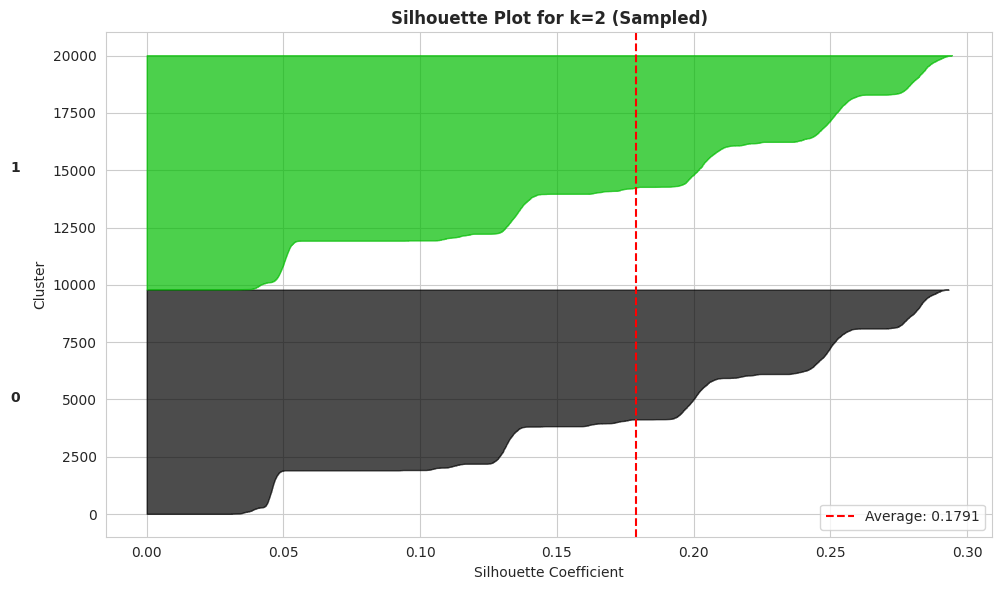

15782

In [12]:
import gc
import cupy as cp
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples

print("Préparation de l'échantillon pour le Silhouette Plot...")

# 1. On s'assure que tout est au format NumPy (CPU)
X_full_cpu = cp.asnumpy(X_full) if hasattr(X_full, "device") else np.asarray(X_full)
labels_cpu = cp.asnumpy(labels_final) if hasattr(labels_final, "device") else np.asarray(labels_final)

# 2. On prend un échantillon de 20 000 lignes au hasard pour éviter le MemoryError
MAX_PLOT_SAMPLES = 20000
if X_full_cpu.shape[0] > MAX_PLOT_SAMPLES:
    np.random.seed(42)
    indices = np.random.choice(X_full_cpu.shape[0], size=MAX_PLOT_SAMPLES, replace=False)
    X_sample = X_full_cpu[indices]
    labels_sample = labels_cpu[indices]
    print(f"Graphique généré sur un échantillon représentatif de {MAX_PLOT_SAMPLES} lignes.")
else:
    X_sample = X_full_cpu
    labels_sample = labels_cpu

# 3. Calcul des silhouettes par échantillon (rapide grâce au limit)
print("Calcul des coefficients de silhouette individuels...")
sil_samples = silhouette_samples(X_sample, labels_sample)
avg_silhouette = np.mean(sil_samples)

# 4. Génération du graphique
print("Génération du graphique...")
fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
for i in range(best_k_final):
    # Extraire et trier les valeurs pour le cluster i
    cluster_sil_vals = sil_samples[labels_sample == i]
    cluster_sil_vals.sort()
    
    size_cluster_i = cluster_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    # Couleur du cluster
    color = cm.nipy_spectral(float(i) / best_k_final)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label du cluster au centre
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')
    y_lower = y_upper + 10

ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f'Silhouette Plot for k={best_k_final} (Sampled)', fontweight='bold')

# Ligne rouge pour la moyenne globale de l'échantillon
ax.axvline(x=avg_silhouette, color="red", linestyle="--", 
           label=f'Average: {avg_silhouette:.4f}')

ax.legend()
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig('04_silhouette_plot.png', dpi=100, bbox_inches='tight')
plt.show()

# Nettoyage final
del X_sample, labels_sample, sil_samples
gc.collect()

## 6. Final Recommendation

In [14]:
print('\n' + '='*70)
print('CLUSTERING ANALYSIS SUMMARY')
print('='*70)
print(f'\nData shape: {X_full.shape}')
print(f'True labels: Binary (COVID vs Non-COVID)')
print(f'\nMetrics Analysis:')

# Utilisation des bons dictionnaires de scores directement avec la clé 'best_k'
print(f'  Silhouette Best: k={best_k} (score={silhouette_scores[best_k]:.4f})')
print(f'  Davies-Bouldin Best: k={best_k_db} (score={db_scores[best_k_db]:.4f})')

print(f'\nRECOMMENDATION:')
if best_k == best_k_db:
    print(f'  BOTH metrics agree: Use k={best_k} clusters')
else:
    recommended = min(best_k, best_k_db)
    print(f'  Metrics differ: Recommend k={recommended} (conservative choice)')
    
print(f'\nConclusion:')
print(f'  Original classification: 4 severity classes')
print(f'  Optimal clusters found: {min(best_k, best_k_db)} clusters')
print(f'  --> Consider reducing to 2-3 classes for production!')
print('='*70)


CLUSTERING ANALYSIS SUMMARY

Data shape: (316800, 23)
True labels: Binary (COVID vs Non-COVID)

Metrics Analysis:
  Silhouette Best: k=2 (score=0.1784)
  Davies-Bouldin Best: k=2 (score=3.0821)

RECOMMENDATION:
  BOTH metrics agree: Use k=2 clusters

Conclusion:
  Original classification: 4 severity classes
  Optimal clusters found: 2 clusters
  --> Consider reducing to 2-3 classes for production!


## 7. Best Clustering Result

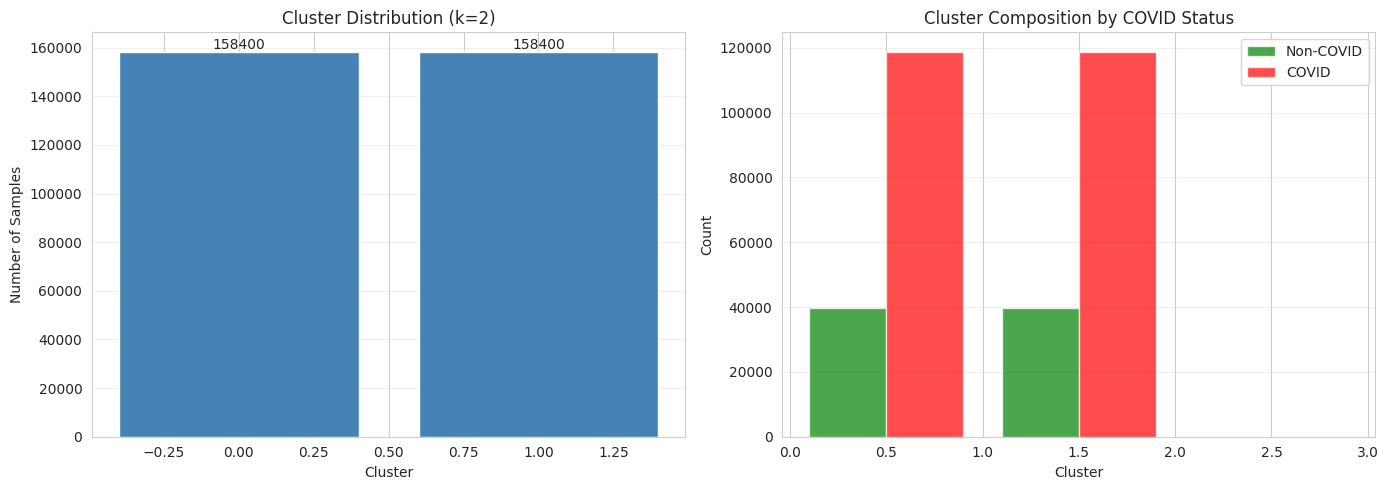

Saved clustering visualization


In [15]:
best_k_final = min(best_k, best_k_db)
kmeans_final = KMeans(n_clusters=best_k_final, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_full)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
unique, counts = np.unique(labels_final, return_counts=True)
axes[0].bar(unique, counts, color='steelblue')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title(f'Cluster Distribution (k={best_k_final})')
axes[0].grid(True, alpha=0.3, axis='y')
for i, (cluster, count) in enumerate(zip(unique, counts)):
    axes[0].text(cluster, count, f'{count}', ha='center', va='bottom')
covid_0 = (labels_final[y_full == 0]).tolist()
covid_1 = (labels_final[y_full == 1]).tolist()
axes[1].hist([covid_0, covid_1], bins=range(best_k_final+2), label=['Non-COVID', 'COVID'], color=['green', 'red'], alpha=0.7)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_title('Cluster Composition by COVID Status')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('03_best_clustering.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Saved clustering visualization')

## 8. Save Results

In [17]:
import pickle
import numpy as np
import cupy as cp

# 1. Alignement des variables de scores
# (Ajuste les noms à droite du '=' si tes variables s'appellent autrement dans ton notebook)
k_a_sauvegarder = best_k  
sil_a_sauvegarder = silhouette_scores  
db_a_sauvegarder = db_scores

# 2. SÉCURITÉ GPU : On transfère les labels et y_true sur le CPU (NumPy) avant le pickle
labels_cpu = cp.asnumpy(labels_final) if hasattr(labels_final, "device") else np.asarray(labels_final)
y_true_cpu = cp.asnumpy(y_full) if hasattr(y_full, "device") else np.asarray(y_full)

# 3. Sauvegarde des données classiques (scores, labels, etc.)
clustering_summary = {
    'best_k': k_a_sauvegarder,
    'silhouette_scores': sil_a_sauvegarder,
    'davies_bouldin_scores': db_a_sauvegarder,
    'cluster_labels': labels_cpu,
    'y_true': y_true_cpu
}

with open('clustering_summary.pkl', 'wb') as f:
    pickle.dump(clustering_summary, f)
print('Saved: clustering_summary.pkl (Données et scores)')

# 4. Sauvegarde du modèle cuKMeans avec pickle standard (supporté par cuML)
with open('kmeans_final_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print('Saved: kmeans_final_model.pkl (Modèle GPU)')

Saved: clustering_summary.pkl (Données et scores)
Saved: kmeans_final_model.pkl (Modèle GPU)
